In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [4]:
file_path = 'zomato_raw_data.csv'
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [5]:
pd.read_csv(file_path)

,user_id,session_id,event,timestamp,device,city,channel,cuisine_category,revenue
0,USR03122,SES03122,App Open,2024-01-01 00:53:57,Mobile,Kolkata,Google Ads,Biryani,0.0
1,USR03122,SES03122,Search,2024-01-01 01:01:57,Mobile,Kolkata,Google Ads,Biryani,0.0
2,USR03122,SES03122,Restaurant Viewed,2024-01-01 01:08:57,Mobile,Kolkata,Google Ads,Biryani,0.0
3,USR03122,SES03122,Add to Cart,2024-01-01 01:14:57,Mobile,Kolkata,Google Ads,Biryani,0.0
4,USR03494,SES03494,App Open,2024-01-01 04:05:21,Mobile,Delhi,Organic,Desserts,0.0
...,...,...,...,...,...,...,...,...,...
18083,USR02101,SES02101,Checkout,2024-10-30 20:45:59,Mobile,Bangalore,Organic,Desserts,0.0
18084,USR02101,SES02101,Payment,2024-10-30 20:47:59,Mobile,Bangalore,Organic,Desserts,0.0
18085,USR02101,SES02101,Order Placed,2024-10-30 20:52:59,Mobile,Bangalore,Organic,Desserts,621.2
18086,USR01806,SES01806,App Open,2024-10-30 23:40:21,Tablet,Delhi,Google Ads,South Indian,0.0


In [6]:
funnel_stage = ['App Open', 'Search', 'Restaurant Viewed', 'Add to Cart',
       'Order Placed', 'Checkout', 'Payment']

In [7]:
def cleaning(file_path):
    df = pd.read_csv(file_path)

    df['timestamp'] = pd.to_datetime(df['timestamp'])

    df = df.drop_duplicates()
    df = df.dropna(subset=['user_id', 'event', 'channel'])

    df['month'] = df['timestamp'].dt.to_period('M')
    df['week'] = df['timestamp'].dt.to_period('W')
    df['date'] = df['timestamp'].dt.date

    return df

In [8]:
def summary(df):
    # 1. % of people that opened the app and added something to the cart 
    summary_df = df.groupby('session_id').agg(
        {
            'user_id':'first',
            'timestamp':['min','max'],
            'event' : lambda x: list(x),
            'device':'first',
            'city':'first',
            'channel':'first',
            'cuisine_category':'first',
            'revenue':'max'
        }
    ).reset_index()
    summary_df.columns = ['session_id','user_id','session_start','session_end','event_sequence','device','city','channel','cuisine_category','revenue']
    
    # summary_df['session_start'] = pd.to_datetime(summary_df['session_start'])
    # summary_df['session_end'] = pd.to_datetime(summary_df['session_end'])

    summary_df['month'] = summary_df['session_end'].dt.to_period('M')
    summary_df['week'] = summary_df['session_end'].dt.to_period('W')
    summary_df['date'] = summary_df['session_end'].dt.date

    
    summary_df['session_duration'] = (summary_df['session_end'] - summary_df['session_start']).dt.total_seconds()/60
    
    return summary_df

In [9]:
def acquired_customers(df):

    temp_df = df.groupby('user_id')['date'].min().reset_index()
    
    temp_df['a_month'] = pd.to_datetime(temp_df['date']).dt.to_period('M')
    
    return temp_df

In [10]:
def max_funnel_stage(events):
    global funnel_stage
    stage_values = {stage:i for i,stage in enumerate(funnel_stage)}

    max_stage_index = -1

    for event in events:
        if event in stage_values and max_stage_index<stage_values[event]:
            max_stage_index = stage_values[event]
    return funnel_stage[max_stage_index] if max_stage_index !=-1 else 'App Open'

In [11]:
df = cleaning(file_path)
summary_df = summary(df)
customer_acquired_df = acquired_customers(df)
# summary_df = summary_df.merge(customer_acquired_df,on=['user_id'])

In [12]:
summary_df['max_funnel_stage'] = summary_df['event_sequence'].apply(max_funnel_stage)

In [13]:
payment_df = summary_df[summary_df['revenue']>0]
len(payment_df)

1718

In [14]:
location_channel_pivot = pd.pivot_table(payment_df,index='city',columns='channel',values='user_id',aggfunc='nunique')

In [15]:
total_users = pd.pivot_table(summary_df,index='city',columns='channel',values='user_id',aggfunc='nunique')

In [16]:
conversion_df = ((location_channel_pivot/total_users)*100).round(2)

### Customer Acquisition by location and channel

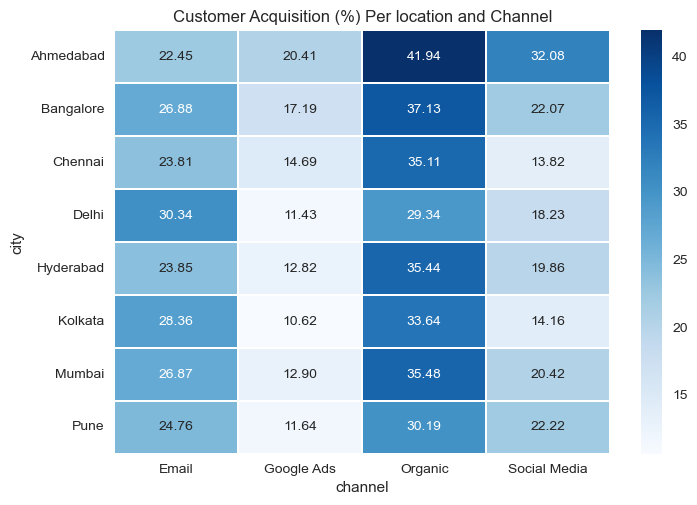

In [68]:
sns.heatmap(conversion_df,annot=True,fmt='.2f',linewidth=1.2,cmap='Blues')
plt.title('Customer Acquisition (%) Per location and Channel')
plt.show()

### Acquisition Channel and total revenue earned

In [18]:
pivot = pd.pivot_table(payment_df,index='city',columns='channel',values='revenue',aggfunc='sum')

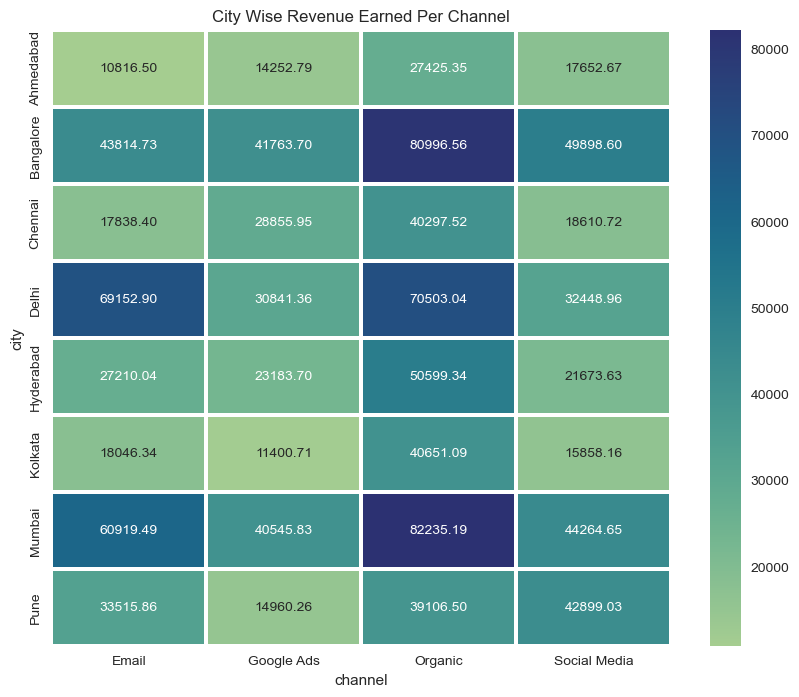

In [69]:
plt.figure(figsize=(10,8))
sns.heatmap(pivot,annot=True,fmt='.2f',linewidth=1.5,cmap='crest')
plt.title('City Wise Revenue Earned Per Channel')
plt.show()

### City & Channel Insights

<div class="alert alert-info">
<b>Observation:</b> Google Ads has the lowest purchase conversion rate 
across ALL 8 cities consistently — ranging from 10.62% (Kolkata) to 
20.41% (Ahmedabad). 
</div>


**Hypothesis:**
            
* Google Ads might not be promoting the right product to the Consumer.
    
* Google Ads are working exceptionally well for Ahmedabad indicating less competitor noise and fewer alternative food options.

* Could be that Competitors Ads are more relevant to the users or users switch to a competitor offering a better deal at the same moment.



### Revenue earned by acquistion Channel Each Month

In [20]:
channel_month_revenue_pivot = pd.pivot_table(summary_df[summary_df['revenue']>0],index='channel',columns='month',values='revenue',aggfunc='sum')

In [21]:
channel_month_revenue_pivot

month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10
channel,,,,,,,,,,
Email,20131.84,24728.88,28952.21,28867.25,35206.72,31812.71,31820.00,30507.32,25692.06,23595.27
Google Ads,16135.58,18872.32,20837.27,24387.11,24600.31,20390.70,18991.10,16880.23,21794.61,22915.07
Organic,32220.43,37549.94,43561.06,36227.65,43655.71,36690.53,45883.49,52354.03,53214.89,50456.86
Social Media,11210.44,17649.49,19856.54,22612.55,29675.29,30700.47,26286.50,31239.10,26821.78,27254.26


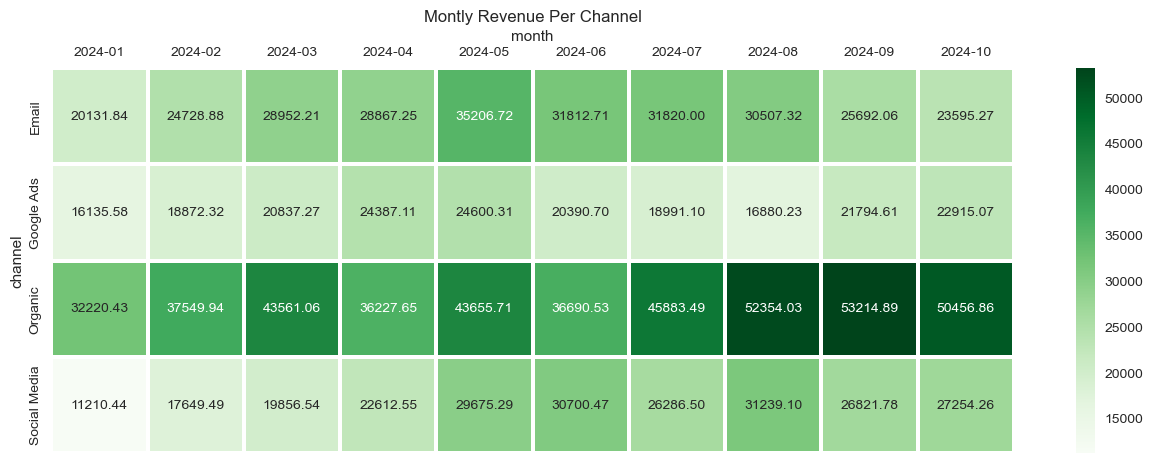

In [22]:
fig,ax = plt.subplots(1,1,figsize=(16,5))
sns.heatmap(data=channel_month_revenue_pivot,fmt='.2f',annot=True,linewidth=1.7,square=True,cmap='Greens',ax=ax)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Montly Revenue Per Channel') 
plt.show()

### Customer Gained Each Month by Channel

In [23]:
channel_month_customer_pivot =pd.pivot_table(summary_df,index='channel',columns='month',values='user_id',aggfunc='nunique')

In [24]:
channel_month_customer_pivot 

month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10
channel,,,,,,,,,,
Email,99,98,107,119,126,110,114,112,107,121
Google Ads,176,168,147,147,142,157,158,179,152,165
Organic,150,146,152,139,119,132,146,159,160,158
Social Media,126,136,119,119,158,135,145,141,135,142


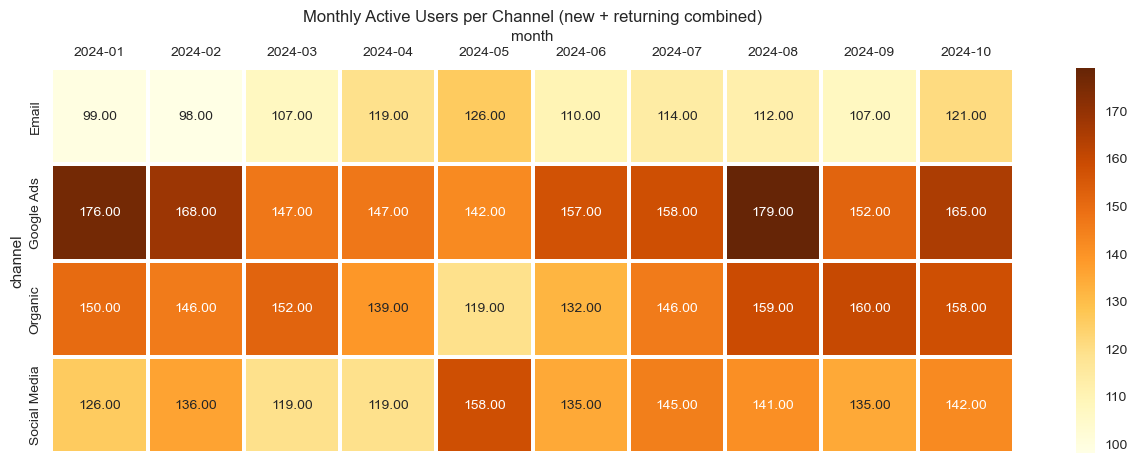

In [25]:
fig,ax = plt.subplots(1,1,figsize=(16,5))
sns.heatmap(data=channel_month_customer_pivot,fmt='.2f',annot=True,linewidth=1.7,square=True,cmap='YlOrBr',ax=ax)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Monthly Active Users per Channel (new + returning combined)') 
plt.show()

### Channel Insights per Month 

<div class="alert alert-info">
<b>Observation:</b> Email attracts least Customers but the customers are Potential buyers i.e Email Converts almost 25% of the Customer it Acquires. 
                    On the Other hand google Attracts huge Volume of customer but can only convert 10-13 % of the customers.
</div>


**Hypothesis:**
            
* Emails are more personalized for each users and they drop them to a specific stage where can they get what they were Advirtiezed about, While Google Ads are more generic for everyone and when someone clicks on the Ad they get redirected to a Normal Home page of the app.
    
    
* Email has the least Impulse Buyer i.e They have the clear intent unlike Google Ads.

* Might be that Customers receving the Emails are also receving a Promo Code or discount we can explain this with the following equation.

     * `Total Email Converston = New Commers + Repeating Users`
                           
         * New Commers will be tempted by the Promo code.
         * Repeating Users Like the roylty they receive by receving email
                           



### Acquisition City and the Total Revenue per Month

In [26]:
city_month_revenue_pivot = pd.pivot_table(summary_df[summary_df['revenue']>0],index='city',columns='month',values='revenue',aggfunc='sum')

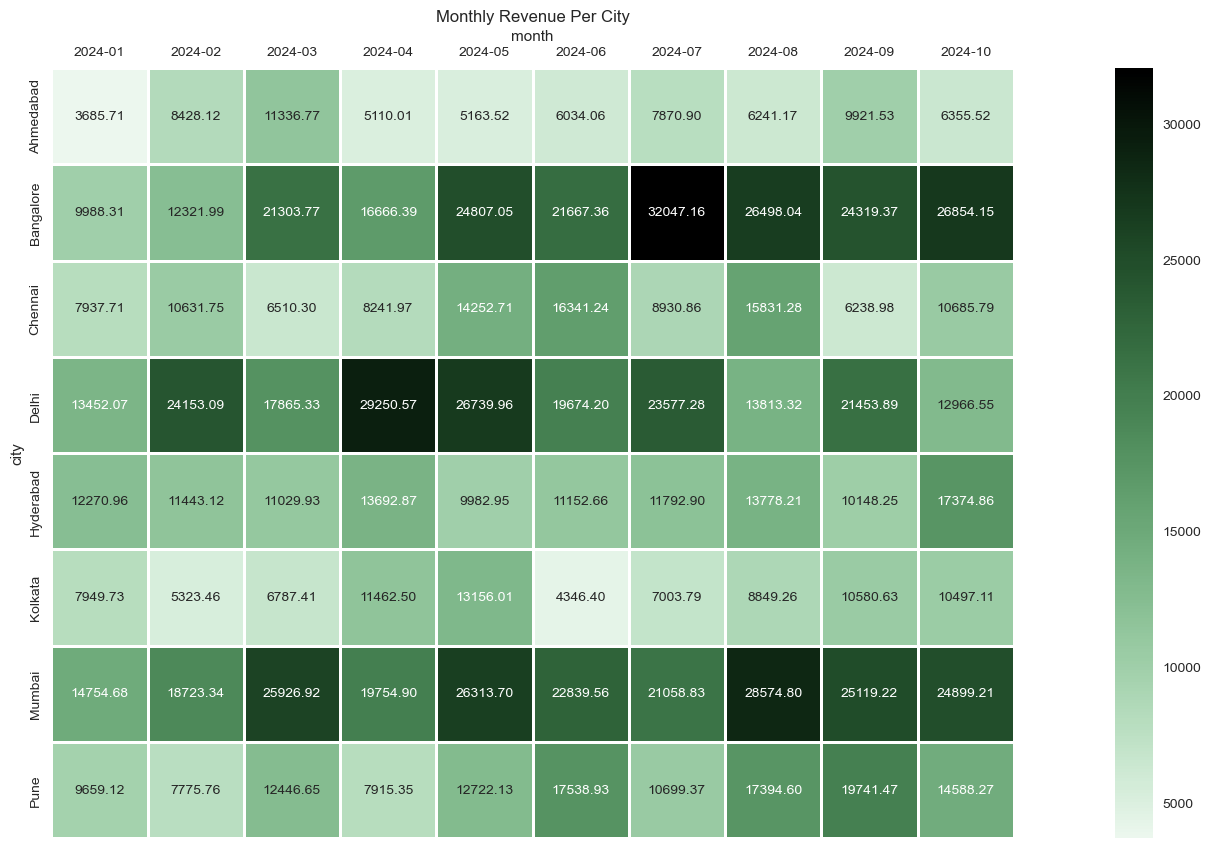

In [27]:
fig,ax = plt.subplots(1,1,figsize=(26,10))
sns.heatmap(data=city_month_revenue_pivot,fmt='.2f',annot=True,linewidth=1.0,square=True,cmap=sns.cubehelix_palette(start=2, rot=0, dark=0, light=.95, reverse=False, as_cmap=True)
,ax=ax)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Monthly Revenue Per City') 
plt.show()

### Acquisition customers per location per Month per channel

In [28]:
city_month_channel_customer_pivot =pd.pivot_table(summary_df,index='city',columns=['month','channel'],values='user_id',aggfunc='nunique')

In [29]:
city_month_channel_customer_pivot

month     2024-01                                 2024-02                     \
channel     Email Google Ads Organic Social Media   Email Google Ads Organic   
city                                                                           
Ahmedabad       5          3      11            7       5          6       6   
Bangalore      12         31      15           23      18         28      19   
Chennai        10         15      10            9       7         19      12   
Delhi          19         36      33           16      19         30      31   
Hyderabad      12         27      19           18      15         22      24   
Kolkata        10         14      14           10       7         16      13   
Mumbai         17         32      35           26      21         29      29   
Pune           14         18      13           17       6         18      12   

month                  2024-03             ... 2024-08              2024-09  \
channel   Social Media   Email Google Ads  ... Organic Social Media   Email   
city                                       ...                                
Ahmedabad            8       7         10  ...       8            5       3   
Bangalore           20      15         32  ...      33           25      20   
Chennai             10       5         10  ...      19           17      12   
Delhi               29      13         24  ...      22           23      23   
Hyderabad           13      12         14  ...      21           15      10   
Kolkata             10      10         10  ...       8           14       8   
Mumbai              28      30         38  ...      34           25      21   
Pune                18      15          9  ...      14           17      10   

month                                     2024-10                     \
channel   Google Ads Organic Social Media   Email Google Ads Organic   
city                                                                   
Ahmedabad          4      12            8       5          7       8   
Bangalore         27      32           27      27         28      30   
Chennai           10      13           10      12         13      19   
Delhi             33      27           25      19         35      24   
Hyderabad         26      13           10      13         29      20   
Kolkata            9      15           14       5         10      17   
Mumbai            27      32           25      23         31      28   
Pune              16      16           16      17         12      12   

month                   
channel   Social Media  
city                    
Ahmedabad            6  
Bangalore           28  
Chennai             17  
Delhi               16  
Hyderabad           17  
Kolkata             14  
Mumbai              25  
Pune                19  

[8 rows x 40 columns]

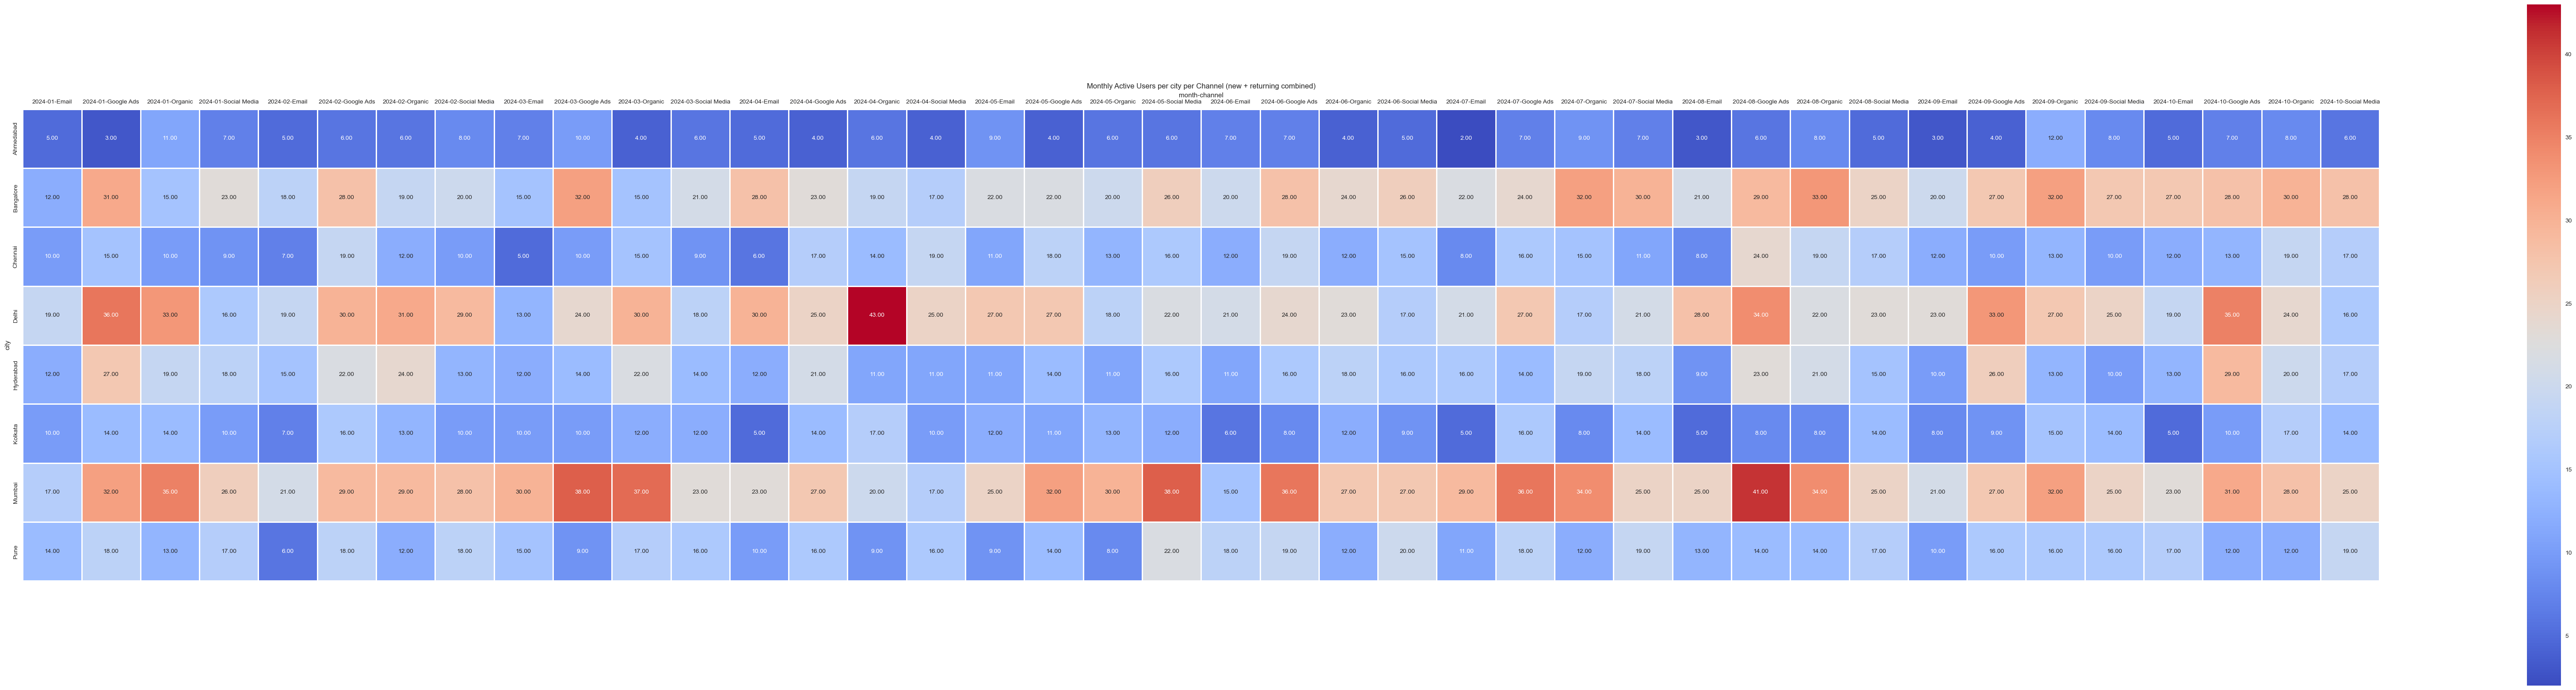

In [30]:
fig,ax = plt.subplots(1,1,figsize=(86,20))
sns.heatmap(data=city_month_channel_customer_pivot,fmt='.2f',annot=True,linewidth=1.0,square=True
            ,cmap='coolwarm'
,ax=ax)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Monthly Active Users per city per Channel (new + returning combined)') 
plt.show()

In [31]:
### Acquisition location per Month per channel

In [32]:
city_month_customer_pivot =pd.pivot_table(summary_df,index='city',columns=['month'],values='user_id',aggfunc='nunique')

In [33]:
city_month_customer_pivot

month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10
city,,,,,,,,,,
Ahmedabad,26,25,27,19,25,23,25,22,27,26
Bangalore,81,85,83,87,90,98,108,108,106,113
Chennai,44,48,39,56,58,58,50,68,45,61
Delhi,104,109,85,123,94,85,86,107,108,94
Hyderabad,76,74,62,55,52,61,67,68,59,79
Kolkata,48,46,44,46,48,35,43,35,46,46
Mumbai,110,107,128,87,125,105,124,125,105,107
Pune,62,54,57,51,53,69,60,58,58,60


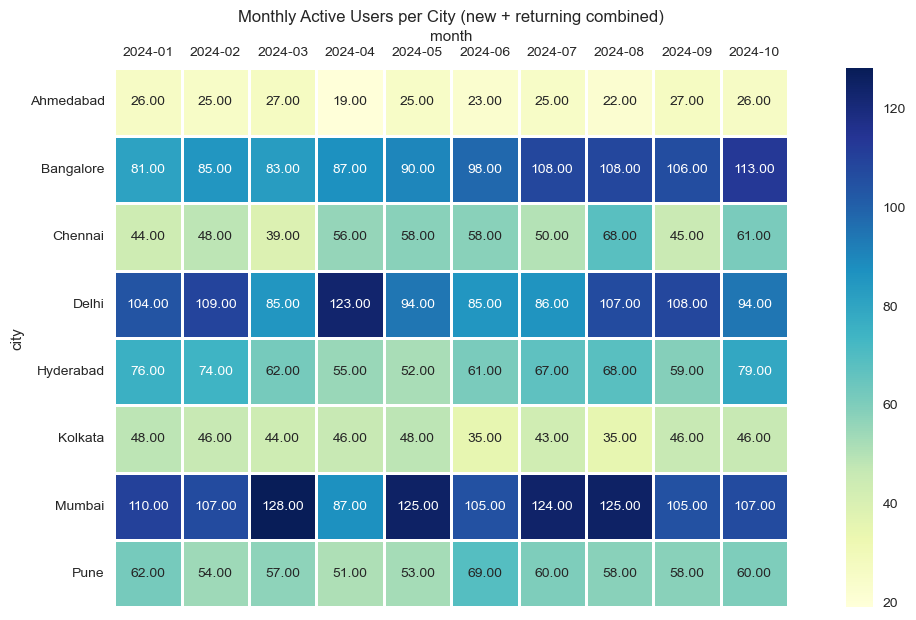

In [34]:
fig,ax = plt.subplots(1,1,figsize=(15,7))
sns.heatmap(data=city_month_customer_pivot,fmt='.2f',annot=True,linewidth=1.0,square=True
            ,cmap='YlGnBu'
,ax=ax)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Monthly Active Users per City (new + returning combined)') 
plt.show()

### Retention Rate by channel per Month

In [35]:
def channel_cohort(summary_df):
    purchase = summary_df[summary_df['revenue']>0].copy()

    customer_acquired_date = purchase.groupby('user_id')['month'].min().reset_index()
    customer_acquired_date.columns = ['user_id','a_month']
    # display(customer_acquired_date)
    combined_df = purchase.merge(customer_acquired_date,on='user_id')
    
    combined_df['period'] = (
    combined_df['month'] - combined_df['a_month']
    ).apply(lambda x: x.n)

    pivot = combined_df.pivot_table(index='channel',columns='period',values='user_id',aggfunc='nunique')
    retention_pct = pivot.divide(pivot[0],axis=0).mul(100).round(2)
    retention_pct = retention_pct.fillna(0)
    fig,ax = plt.subplots(1,1,figsize=(15,7))
    sns.heatmap(data=retention_pct,fmt='.2f',annot=True,linewidth=1.0,square=True
                ,cmap='GnBu'
    ,ax=ax)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    plt.title('User Retention By period') 
    plt.show()

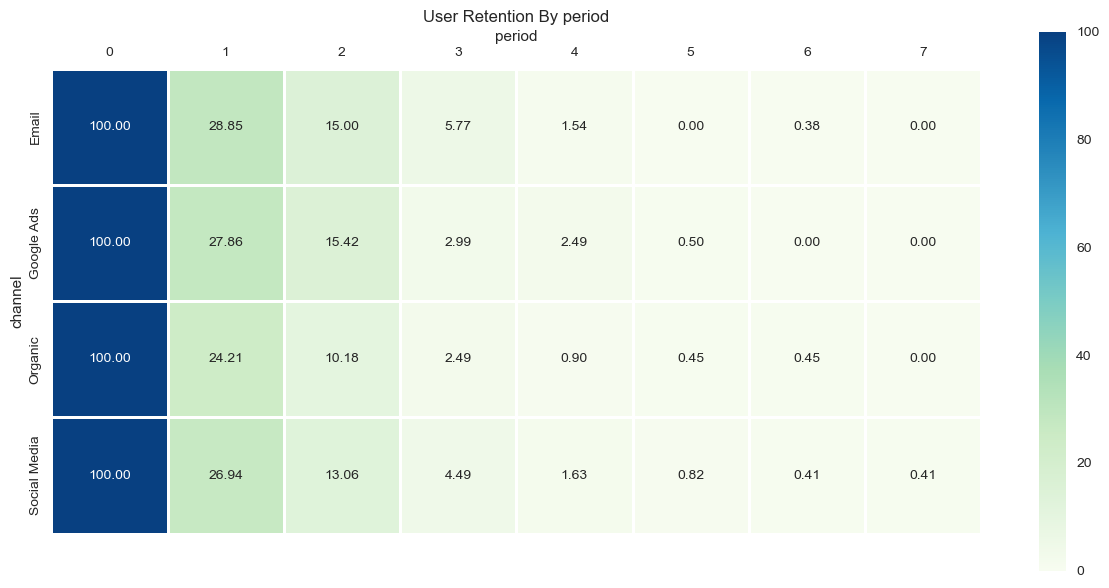

In [36]:
channel_cohort(summary_df)

### Retention Rate Per Month by acquisition month

In [70]:
def acquisition_month_cohort(summary_df):
    purchase = summary_df[summary_df['revenue']>0].copy()

    customer_acquired_date = purchase.groupby('user_id')['month'].min().reset_index()
    customer_acquired_date.columns = ['user_id','a_month']
    # display(customer_acquired_date)
    combined_df = purchase.merge(customer_acquired_date,on='user_id')
    
    combined_df['period'] = (
    combined_df['month'] - combined_df['a_month']
    ).apply(lambda x: x.n)

    pivot = combined_df.pivot_table(index='a_month',columns='month',values='user_id',aggfunc='nunique')

    
    retention_pct = pivot.apply(lambda x: x/x[x.first_valid_index()],axis=1).mul(100).round(2)
    
    # Optional (to replace the NA values with 0)
    retention_pct.iloc[0:5,6::] = retention_pct.iloc[0:5,6::].fillna(0)
    ###################################
    
    fig,ax = plt.subplots(1,1,figsize=(15,7))
    sns.heatmap(data=retention_pct,fmt='.2f',annot=True,linewidth=1.0
                ,cmap='RdYlGn'
    ,ax=ax)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='y',labelrotation=45)
    plt.title('User Retention') 
    plt.show()

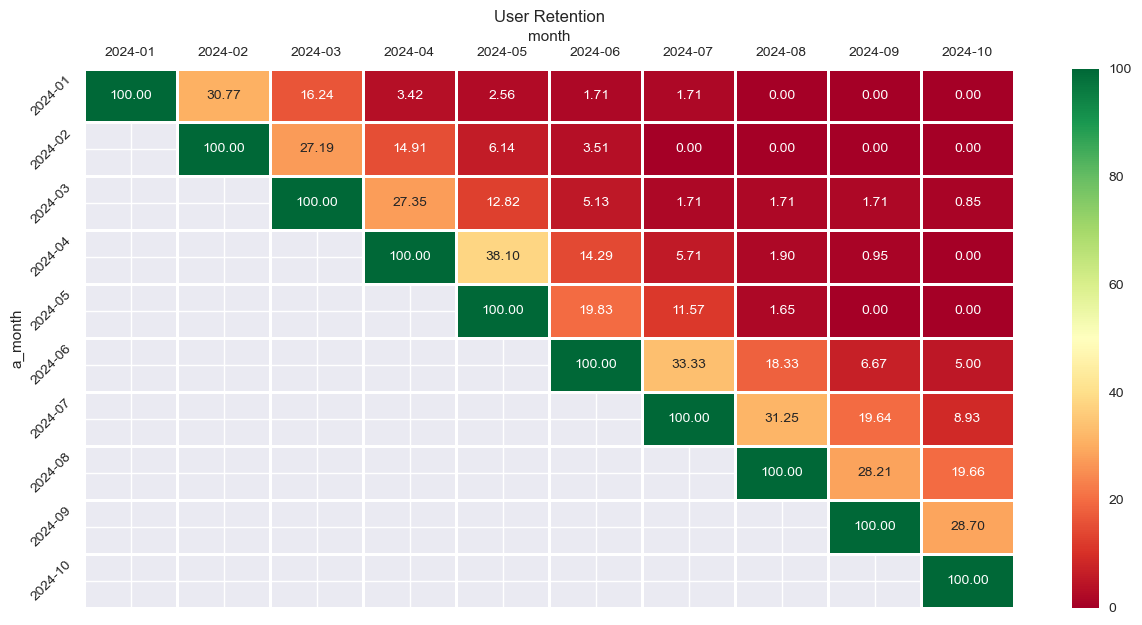

In [71]:
acquisition_month_cohort(summary_df)

### Insights by Acquisition Month 

<div class="alert alert-info">
<b>Observation:</b> Retention drops sharply after 3 months across all cohorts consistently.By month 4, retention falls below 10% regardless of the acquistion period.
</div>


**Hypothesis:**
            
* Users in the first 3 months are evaluating for all the better options.    
    
* By month 3-4 users commit to the App and they dont choose Zomato as their primary platform to order food.

* `New User Bias` were the order delivery or the prices are increased for the old customers and new Customers are priotized hence for each subsequent month their Priority is decreased to the point where users dont find the value for money .


                                                                                                                                                                                                                                                                                             